# BINF TP4 - Evolution de séquences

Dans ce TP nous allons manipuler les méthodes de génération de séquence.

# Exercice 1 - Evolution de séquences

Nous allons simuler des chaînes de Markov pour faire évoluer des séquences d'ADN. Ces chaînes ont 4 états, un pour chaque nucléotide et forment un graphe complet, où chaque état peut transitionner vers chaque autre et vers lui-même. On représente une telle chaîne sous la forme d'une matrice de taux de transitions $Q$ de taille 4$\times$4 où $q_{ij}$ donne le taux de mutation de $i \rightarrow j$ et
$$q_{ii}=-\sum\limits_{j} q_{ij}$$
de sorte que la somme de chaque ligne soit $0$.

On simule une telle chaîne en deux étapes :

1. En considérant que l'état actuel est $i$, le temps de résidence $\tau$ dans l'état correspond au temps avant qu'une transition sortante ne se produise, ce qui est fonction de $-q_{ii}$. Plus précisément, pour une chaîne de Markov en temps continue, ce temps est une valeur aléatoire distribuée selon une loi exponentielle :
$$τ \sim exp(-q_{ii}).$$

2. Une fois qu'on a déterminé le temps de sortie, il faut choisir l'état d'arrivé. La probabilité de sauter vers un autre état $j \neq i$ est donnée par :
$$p_{ij}=\frac{q_{ij}}{-q_{ii}}.$$
Appelons $u,v,w$ les trois états sortants de $i$ et formons le vecteur de leurs probabilitées cumulées
$$S=[p_{iu},p_{iu}+p_{iv},p_{iu}+p_{iv}+p_{iw}].$$
On va alors tirer une valeur aléatoire distribuée uniformément dans $[0,1]$ : $u \sim U([0,1])$ et chercher l'indice $k^*$ de l'élément minimum dans $S$ tel que $u \leq s_{k^*}$. Si $k^*$=0 alors l'état suivant est $u$, si $k^*=1$ c'est $v$ et si $k^*$=2 c'est $w$.

On va répéter ces deux opérations tant que $t<t_{max}$ avec à chaque itération $t=t+\tau$.

Q1. Implémentez cette simulation pour $t_{max} = 50$ ans, un caractère initial "A" et la matrice $Q$ suivant le modèle JC69 avec $\mu = 0.1$ mutations par an.

In [44]:
import numpy as np
from numpy import random as rnd

def run_MC(tmax, Q, s0, bases):
    charmap = {n: bases.find(n) for n in bases}
    s = s0

    t = 0
    while t < tmax:
        i = charmap[s[-1]]
        qq = np.abs(Q[i,i])
        dt = rnd.exponential(1/qq)

        if t + dt > tmax:
            t = tmax
            break

        cprs = np.cumsum(np.array([Q[i,k] for k in range(4) if k != i]) / qq)
        u = rnd.rand()
        j = np.min(np.where(u < cprs))

        curbases = [bases[k] for k in range(4) if k != i]
        s += curbases[j]
        t = t+dt
    return s

In [45]:
mu = 0.1
bases ="AGCT"

#JC69
Q = np.array([[-3/4, 1/4, 1/4, 1/4],
               [1/4, -3/4, 1/4, 1/4],
               [1/4, 1/4, -3/4, 1/4],
               [1/4, 1/4, 1/4, -3/4]]) * mu

print(run_MC(50, Q, "A", bases)[-1])

T


Q2. En utilisant les même paramètres qu'a la question précédente, simulez l'évolution de la séquence s0 = ATTGCGTAGCTAC

In [46]:
print("".join([run_MC(50, Q, c, bases)[-1] for c in "ATTGCGTAGCTAC"]))

CCCATGACTCATT


Q3. Même chose que la question 2 mais cette fois avec la matrice $Q$ suivant le modèle HYK85 avec la fréquence d'apparition de chaque caractère $\pi_n$ calculée sur s0 et $\kappa = 5$.

In [47]:
s0 = "ATTGCGTAGCTAC"
pi = {n: s0.count(n) / len(s0) for n in bases}
kappa = 5
Q = np.array([[-kappa*pi["G"]-pi["C"]-pi["T"], kappa*pi["G"], pi["C"], pi["T"]],
              [kappa*pi["A"], -kappa*pi["A"]-pi["C"]-pi["T"], pi["C"], pi["T"]],
              [pi["A"], pi["G"], -pi["A"]-pi["G"]-kappa*pi["T"], kappa*pi["T"]],
              [pi["A"], pi["G"], kappa*pi["C"], -pi["A"]-pi["G"]-kappa*pi["C"]]]) * mu

print("".join([run_MC(50, Q, c, bases)[-1] for c in "ATTGCGTAGCTAC"]))

CAGGATACGGCAC


Q4. Faites varier $\kappa$ et regardez l'effet sur les séquences générées, en calculant le GC-content en fonction de $\kappa$ pour $\kappa = [0, 0.1, 0.2, ..., 20]$.

(0.0, 1.0)

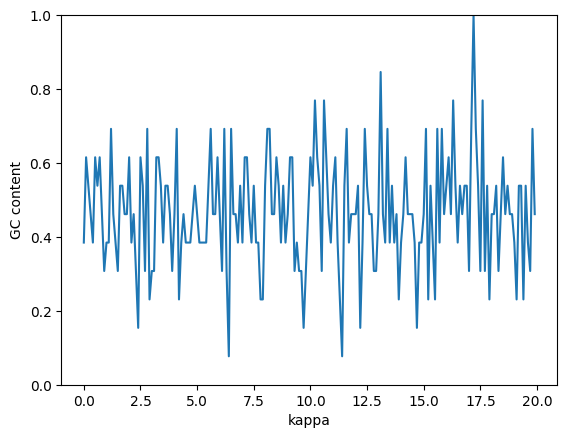

In [48]:
gcs = []
kappas = np.arange(0, 20, 0.1)
for kappa in kappas:
  Q = np.array([[-kappa*pi["G"]-pi["C"]-pi["T"], kappa*pi["G"], pi["C"], pi["T"]],
                [kappa*pi["A"], -kappa*pi["A"]-pi["C"]-pi["T"], pi["C"], pi["T"]],
                [pi["A"], pi["G"], -pi["A"]-pi["G"]-kappa*pi["T"], kappa*pi["T"]],
                [pi["A"], pi["G"], kappa*pi["C"], -pi["A"]-pi["G"]-kappa*pi["C"]]]) * mu
  res = "".join([run_MC(50, Q, c, bases)[-1] for c in "ATTGCGTAGCTAC"])
  gcs.append((res.count("G") + res.count("C")) / len(res))

from matplotlib import pyplot as plt
plt.figure()
plt.plot(kappas, gcs)
plt.ylabel("GC content")
plt.xlabel("kappa")
plt.ylim([0, 1])

Q5. Basé sur le modèle JC69 avec $\mu = 0.1$ mutation par an, générez 100 séquences dérivées de s0=ATTGCGTCGTAGCTGCGTCGTATTGCGTCGTAGCTGC jusqu'à tmax = 500 ans.


In [49]:
mu = 0.1
bases ="AGCT"

#JC69
Q = np.array([[-3/4, 1/4, 1/4, 1/4],
               [1/4, -3/4, 1/4, 1/4],
               [1/4, 1/4, -3/4, 1/4],
               [1/4, 1/4, 1/4, -3/4]]) * mu

s0 = "ATTGCGTCGTAGCTGCGTCGTATTGCGTCGTAGCTGCTATTGCGTCGTAGCT"

res = ["".join([run_MC(500, Q, c, bases)[-1] for c in s0]) for i in range(100)]

Q6. Affichez la supperposition de ces séquences

In [50]:
for r in res:
  print(r)

ACTCGTACGCCATTGCTGGCTCAAGTCGCAATTACCATTACGTGGAAATCAT
GCATACAGGGTACTAAATGCTTGTACTCATATGCACTGGTTCCAAGGGCTGT
ATCCGAGAACACCGGCATTTGCCCTATACTCTCCAAAGTTAGACCTCTGCGC
GAAATAACGCCCGTGTCGCTCTGTGGTGGCGCTGTATATATCGCGTCAAGAA
CCCCACCACCCCACGCCGCGGGGTCTCCCAGGCTCTTCGTCGACGATTCGTG
GGTTTTCCATCCAGAAGCTATTGCGTGGGCAAATAATAATATCAAGGGCCCT
TGGCAGATAAACTGTATCGGCATAGCTAATCATAGGGGGTCTATTAGATCAA
CGGAGAAAACCGTGTTCACACCTACAAGCCTTCGTCCTTGACGAATCGCCCA
GAACTTAACGCCTTCAACCGGGATAGAGGGCGATCCTAACGGGTAGCGAATC
CCTAGGTGGACAGACGGAGCCTCCCCTATCACTTCCTAGTAGCTCATGAACC
GTCATTATAGACCATAACTAAGCATTTCCCACTTAGATACCCAATTGTGGAG
CTGGACAACCAAACTTAGCGAGTGCGGATTTGGCGCATCACGTGTTGTTAGG
AGTAGGTAAGAGAGCTCTAACAATAGAAAGATATCGAATACGCCCATCGTCA
TGGACCTAGTTCACCTGGGTTCAAGTGAACAGGATGGACGTGCCGCTCTCGG
CTGCGATTCACGCCAGGCCACCATACATCGAGCCGCAGTAGTATCCAACCAA
AGTTATCCCAGGTGAGCTGCTATCTGATCCTAGAATTTAGCGAACTTAGCGG
AAACGGCTGACGACTATACACCCTTACAGGTATGCGTAACAGTCCGTATGAG
ACTGCGCCCAAAGATCCTTAATACGGGTGACCCATAAGATACCCCGATAGCG
TGGACGCTGCATGTCCTAATGTTCATTTAAATTTAGATGCTGTAAT

Q7. On ne peut pas voir grand chose juste en regardant cette superposition. Ce qui nous intéresse est de savoir si des informations de s0 ont été préservées dans ces séquences. Pour celà, on va calculer la fréquence d'apparition de chaque base à chaque position dans toutes les séquences. On peut représenter celà de manière graphique sous la forme d'un logo, pour faire celà, copiez/collez vos séquences alignées sur ce site:  [weblogo](https://weblogo.threeplusone.com/create.cgi) avec l'option "probability" pour Units.

Qu'observez vous?

```markdown
Il n'y a aucun signal conservé, chaque nucléotide apparaît avec une probabilité 1/4.
```

# Exercice 2 : Algorithme de Levenshtein - version récursive

Q1. Ecrivez la fonction

levenshtein(x: str, y: str) -> int

qui retourne la distance de Levenshtein entre les séquences x et y en utilisant la  version récursive de l'algorithme.

In [51]:
def levenshtein(x, y):
    if x == "":
        return len(y)
    if y == "":
        return len(x)
    if x[0] == y[0]:
        return levenshtein(x[1:], y[1:])
    return 1 + min([levenshtein(x[1:], y[1:]),
                    levenshtein(x[1:], y),
                    levenshtein(x, y[1:])])


Q2. Vous pouvez tester votre code sur les exemples suivants:


*   $L(CCAG, CA) = 2$
*   $L(CCGT, CGTCA) = 3$
*   $L(AY678264^*, OQ870305^*) = 310$

$^*$ ids genbank de deux sequences.

In [52]:
print("𝐿(𝐶𝐶𝐴𝐺,𝐶𝐴) =", levenshtein("CCAG", "CA"))
print("𝐿(𝐶𝐶𝐺𝑇,𝐶𝐺𝑇𝐶𝐴) =", levenshtein("𝐶𝐶𝐺𝑇", "𝐶𝐺𝑇𝐶𝐴"))

𝐿(𝐶𝐶𝐴𝐺,𝐶𝐴) = 2
𝐿(𝐶𝐶𝐺𝑇,𝐶𝐺𝑇𝐶𝐴) = 3


# Exercice 3 : Distance en fonction du temps d'évolution

On va combiner les deux exercices précédents et calculer la distance entre des séquences évoluées et la séquence ancestrale en fonction du temps.

Q1. Génerez une séquence aléatoire $s_0$ de 50 nucléotides

In [53]:
def genseq(N):
    return "".join(["ATGC"[k] for k in np.random.randint(0, 4, N)])

In [54]:
s0 = genseq(50)
print(s0)

AGTTTAAACATCGATAGCATCATGAATATCGCGCGTTCGAATTAAGAGGA


Q2. Faites évoluer $s_0$ selon le modèle JC69 avec $\mu = 0.1$ mutations par an. Utilisez les temps maximum suivants: $[0, 1, 2, 3, ..., 15]$.
Pour chaque temps maximum, générez 10 séquences différentes.

In [55]:
mu = 0.1
bases ="AGCT"

#JC69
Q = np.array([[-3/4, 1/4, 1/4, 1/4],
               [1/4, -3/4, 1/4, 1/4],
               [1/4, 1/4, -3/4, 1/4],
               [1/4, 1/4, 1/4, -3/4]]) * mu

ss = [["".join([run_MC(n, Q, c0, bases) for c0 in s0]) for k in range(10)] for n in range(16)]

Q3. Pour chaque séquence à chaque pas de temps, calculez sa distance de Levenshtein avec la séquence ancestrale $s_0$

In [56]:
#Here I'm using the iterative levenshtein version to speed things up
def levenshtein_mat(x, y):
    S = np.zeros((len(x)+1, len(y)+1))
    B = [[None]*(len(y)+1) for f in range(len(x)+1)]

    for i in range(1, len(x)+1):
        for j in range(1, len(y)+1):
            if x[i-1] == y[j-1]:
                S[i,j] = S[i-1, j-1]
                B[i][j] = (i-1, j-1)
            else:
                vs = [S[i-1,j-1], S[i,j-1], S[i-1,j]]

                idx = np.argmin(vs)
                S[i,j] = 1 + vs[idx]
                B[i][j] = [(i-1,j-1), (i,j-1), (i-1,j)][idx]

    return S[len(x), len(y)]

In [57]:
dss = np.array([[levenshtein_mat(s0, s) for s in ss1] for ss1 in ss])

Q4. Affichez la distance moyenne (sur les distances calculées à chaque pas de temps) en fonction du temps d'évolution.

Text(0, 0.5, 'Levenshtein distance')

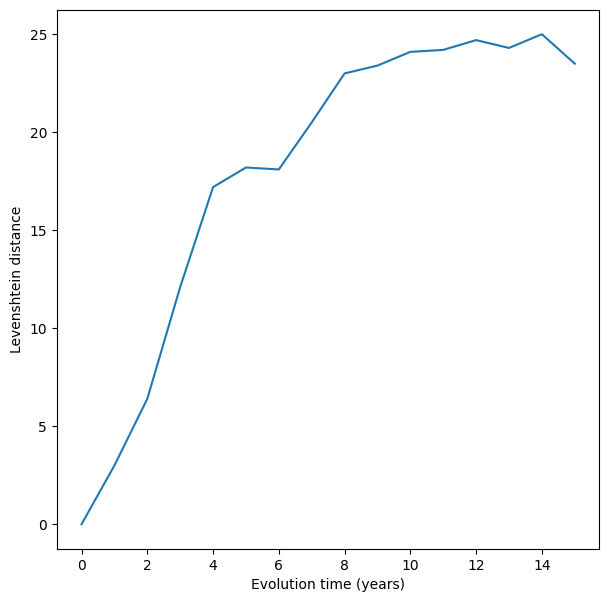

In [58]:
from matplotlib import pyplot as plt

plt.figure(figsize=(7,7))
plt.plot(range(16), np.mean(dss, axis=1))
plt.xlabel('Evolution time (years)')
plt.ylabel('Levenshtein distance')

Q5. Qu'observez-vous? Est-ce en accord avec votre intuition ?

Plus on augmente le temps d'évolution moins la séquence ressemble à la séquence ancestrale. Cela fait sens car plus de temps d'évolution = plus de mutations accumulées.